In [1]:
import pandas as pd

csv_path = "new_flight_analysis_summary.csv"

df = pd.read_csv(csv_path)

print("✅ CSV 로드 완료")
print("행 수:", len(df))
df.head()


✅ CSV 로드 완료
행 수: 2843943


,Unnamed: 0,출발/도착,공항명,항공사,편명,도착지,일자,계획시간,예상시간,출발시간,...,도착시간,지연_분,일자_dt,출발시간_clean,departure_datetime,dep_hour,dep_weekday,is_weekend,is_delay,flight_type
0,0,출발,인천,에미레이트항공,EK323,두바이,20180201,5.0,2350.0,27.0,...,NaN,22.0,2018-02-01,27,2018-02-01 00:27:00,0,3,0,0,국제
1,1,출발,인천,대한항공,KE473,말레,20180201,5.0,2330.0,0.0,...,NaN,-5.0,2018-02-01,0,2018-02-01 00:00:00,0,3,0,0,국제
2,2,출발,인천,말레이시아항공,MH039D,쿠알라룸푸르,20180201,10.0,2030.0,2049.0,...,NaN,1239.0,2018-02-01,2049,2018-02-01 20:49:00,20,3,0,1,국제
3,3,출발,인천,에티하드,EY873,아부다비,20180201,15.0,15.0,17.0,...,NaN,2.0,2018-02-01,17,2018-02-01 00:17:00,0,3,0,0,국제
4,4,출발,인천,타이에어아시아엑스,XJ703,돈므앙(방콕),20180201,20.0,20.0,22.0,...,NaN,2.0,2018-02-01,22,2018-02-01 00:22:00,0,3,0,0,국제


In [2]:
# =====================================================
# 2️⃣ departure_datetime dtype 보장 (★ 중요)
# =====================================================
df["departure_datetime"] = pd.to_datetime(
    df["departure_datetime"],
    errors="coerce"
)

print("departure_datetime dtype:", df["departure_datetime"].dtype)
print("departure_datetime NaT 개수:", df["departure_datetime"].isna().sum())

departure_datetime dtype: datetime64[ns]
departure_datetime NaT 개수: 0


In [3]:
import pandas as pd

df_weather = pd.read_csv(
    "airport_merged_all_plus_final.csv",
    encoding="euc-kr"
)


print("✅ 날씨 CSV 로드 완료")
print("행 수:", len(df_weather))
print("컬럼 수:", df_weather.shape[1])

df_weather.head()


C:\Users\Admin\AppData\Local\Temp\ipykernel_13208\1538714707.py:3: DtypeWarning: Columns (5,26) have mixed types. Specify dtype option on import or set low_memory=False.
  df_weather = pd.read_csv(


✅ 날씨 CSV 로드 완료
행 수: 1041914
컬럼 수: 28


,지점,지점명,일시,일기현상,1층 운량(1/8),1층 운형,1층 운고(FT),기온(°C),이슬점온도(°C),해면기압(hPa),...,중하층운량(10분위),현상번호(국내식),지면온도(°C),풍속_ms,풍향_deg,시정_m,전운량_okta,1층 운고(FT)_결측여부,운형(운형약어),최저운고(100m )
0,156,광주,2023-04-30 01:00:00,없음,0.0,없음,NaN,10.1,7.1,1012.6,...,9.0,0.0,11.0,1.0,NaN,2000.0,7.0,1.0,NaN,NaN
1,156,광주,2023-04-30 02:00:00,없음,0.0,없음,NaN,9.8,6.8,1012.3,...,7.0,0.0,9.4,1.4,NaN,2000.0,6.0,1.0,NaN,NaN
2,156,광주,2023-04-30 03:00:00,없음,0.0,없음,NaN,9.2,6.8,1012.2,...,2.0,0.0,8.3,0.9,NaN,2000.0,2.0,1.0,NaN,NaN
3,156,광주,2023-04-30 04:00:00,없음,0.0,없음,NaN,8.6,6.8,1012.2,...,0.0,0.0,7.6,0.1,NaN,2000.0,0.0,1.0,NaN,NaN
4,156,광주,2023-04-30 05:00:00,없음,0.0,없음,NaN,8.5,7.4,1012.6,...,0.0,0.0,6.9,0.1,NaN,2000.0,0.0,1.0,NaN,NaN


In [4]:
# =========================
# 🔍 컬럼별 결측치 현황
# =========================

missing_summary = (
    df_weather
    .isna()
    .sum()
    .reset_index()
)

missing_summary.columns = ["column", "missing_cnt"]
missing_summary["missing_ratio"] = missing_summary["missing_cnt"] / len(df_weather)
missing_summary["dtype"] = missing_summary["column"].map(
    lambda c: df_weather[c].dtype
)

# 결측치 있는 컬럼만
missing_summary = missing_summary[missing_summary["missing_cnt"] > 0]

# 결측 비율 기준 정렬
missing_summary = missing_summary.sort_values(
    "missing_ratio", ascending=False
)

print("📊 날씨 데이터 컬럼별 결측치 현황")
display(missing_summary)


📊 날씨 데이터 컬럼별 결측치 현황


,column,missing_cnt,missing_ratio,dtype
27,최저운고(100m ),1029259,0.987854,float64
26,운형(운형약어),1029033,0.987637,object
6,1층 운고(FT),940216,0.902393,float64
4,1층 운량(1/8),720855,0.691857,float64
5,1층 운형,720855,0.691857,object
25,1층 운고(FT)_결측여부,720855,0.691857,float64
22,풍향_deg,555837,0.533477,float64
18,중하층운량(10분위),508468,0.488013,float64
20,지면온도(°C),487198,0.467599,float64
13,증기압(hPa),486371,0.466805,float64


In [5]:
df_weather.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041914 entries, 0 to 1041913
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   지점              1041914 non-null  int64  
 1   지점명             1041914 non-null  object 
 2   일시              1041914 non-null  object 
 3   일기현상            1018970 non-null  object 
 4   1층 운량(1/8)      321059 non-null   float64
 5   1층 운형           321059 non-null   object 
 6   1층 운고(FT)       101698 non-null   float64
 7   기온(°C)          1041645 non-null  float64
 8   이슬점온도(°C)       1041614 non-null  float64
 9   해면기압(hPa)       1041611 non-null  float64
 10  현지기압(hPa)       1041633 non-null  float64
 11  강수량(mm)         1041914 non-null  float64
 12  습도(%)           555556 non-null   float64
 13  증기압(hPa)        555543 non-null   float64
 14  일조(hr)          1041914 non-null  float64
 15  일사(MJ/m2)       1041914 non-null  float64
 16  적설(cm)          1041914 non-null  fl

In [6]:
missing_rate = (
    df_weather.isna().mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing_rate.columns = ["column", "missing_rate"]

missing_rate


,column,missing_rate
0,최저운고(100m ),0.987854
1,운형(운형약어),0.987637
2,1층 운고(FT),0.902393
3,1층 운고(FT)_결측여부,0.691857
4,1층 운량(1/8),0.691857
5,1층 운형,0.691857
6,풍향_deg,0.533477
7,중하층운량(10분위),0.488013
8,지면온도(°C),0.467599
9,증기압(hPa),0.466805


In [7]:
numeric_cols = df_weather.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("📊 수치형 컬럼 개수:", len(numeric_cols))
numeric_cols


📊 수치형 컬럼 개수: 23


['지점',
 '1층 운량(1/8)',
 '1층 운고(FT)',
 '기온(°C)',
 '이슬점온도(°C)',
 '해면기압(hPa)',
 '현지기압(hPa)',
 '강수량(mm)',
 '습도(%)',
 '증기압(hPa)',
 '일조(hr)',
 '일사(MJ/m2)',
 '적설(cm)',
 '3시간신적설(cm)',
 '중하층운량(10분위)',
 '현상번호(국내식)',
 '지면온도(°C)',
 '풍속_ms',
 '풍향_deg',
 '시정_m',
 '전운량_okta',
 '1층 운고(FT)_결측여부',
 '최저운고(100m )']

In [8]:
object_cols = df_weather.select_dtypes(include="object").columns.tolist()

object_cols

['지점명', '일시', '일기현상', '1층 운형', '운형(운형약어)']

In [9]:
# 랜덤 샘플 100개 추출
df_weather_sample = df_weather.sample(n=100, random_state=42)

# 엑셀 저장
sample_path = "airport_final_sample_100.xlsx"
df_weather_sample.to_excel(sample_path, index=False)

print(f"✅ 샘플 100개 엑셀 저장 완료: {sample_path}")


✅ 샘플 100개 엑셀 저장 완료: airport_final_sample_100.xlsx


In [10]:
station_list = (
    df_weather["지점명"]
    .dropna()
    .sort_values()
    .unique()
)

print("✅ 지점명 개수:", len(station_list))
station_list


✅ 지점명 개수: 15


array(['광주', '군산', '김포공항', '김해시', '대구', '무안공항', '양양공항', '여수공항', '울산공항',
       '원주', '인천공항', '제주공항', '진주', '청주', '포항'], dtype=object)

In [11]:
# 출발지 목록 추출
boarding_list = (
    df["출발지"]
    .dropna()
    .sort_values()
    .unique()
)

print("✅ BOARDING_KOR 개수:", len(boarding_list))
boarding_list


✅ BOARDING_KOR 개수: 15


array(['광주', '군산', '김포', '김해', '대구', '무안', '사천', '양양', '여수', '울산', '원주',
       '인천', '제주', '청주', '포항경주'], dtype=object)

In [12]:
# =====================================================
# 3️⃣ weather 지점명 → 출발지 매핑
# =====================================================
weather_to_departure_map = {
    "광주": "광주",
    "대구": "대구",
    "군산": "군산",
    "김포공항": "김포",
    "김해시": "김해",
    "무안공항": "무안",
    "양양공항": "양양",
    "여수공항": "여수",
    "울산공항": "울산",
    "원주": "원주",
    "인천공항": "인천",
    "제주공항": "제주",
    "청주": "청주",
    "포항": "포항경주",
    "진주": "사천"
}


In [13]:
# ✅ 지점명 → 출발지 생성 (핵심)
df_weather["출발지"] = df_weather["지점명"].map(weather_to_departure_map)

print("\n날씨 출발지 유니크:")
print(sorted(df_weather["출발지"].dropna().unique()))



날씨 출발지 유니크:
['광주', '군산', '김포', '김해', '대구', '무안', '사천', '양양', '여수', '울산', '원주', '인천', '제주', '청주', '포항경주']


In [14]:
# =====================================================
# 4️⃣ weather_datetime 생성
# =====================================================
df_weather["weather_datetime"] = pd.to_datetime(
    df_weather["일시"],
    errors="coerce"
)

In [15]:
# =====================================================
# 1️⃣ 정렬 (필수)
# =====================================================
df = df.sort_values("departure_datetime")
df_weather = df_weather.sort_values("weather_datetime")

# =====================================================
# 6️⃣ merge_asof (출발지 + 시간 기준)
# =====================================================

df_merged = pd.merge_asof(
    df,
    df_weather,
    left_on="departure_datetime",
    right_on="weather_datetime",
    left_by="출발지",
    right_by="출발지",
    direction="nearest"
)


In [16]:
# =====================================================
# 7️⃣ 머지 결과 검증
# =====================================================
print("\n📊 머지 결과 요약")
print("전체 flight 행 수:", len(df_merged))
print("날씨 붙은 행 수:", df_merged["weather_datetime"].notna().sum())
print("날씨 미부착 행 수:", df_merged["weather_datetime"].isna().sum())
print("날씨 부착 비율:", df_merged["weather_datetime"].notna().mean())

print("\n출발지별 날씨 부착률")
print(
    df_merged
    .groupby("출발지")["weather_datetime"]
    .apply(lambda x: x.notna().mean())
    .sort_values()
)


📊 머지 결과 요약
전체 flight 행 수: 2843943
날씨 붙은 행 수: 2843934
날씨 미부착 행 수: 9
날씨 부착 비율: 0.999996835379612

출발지별 날씨 부착률
출발지
인천      0.999991
광주      1.000000
군산      1.000000
김포      1.000000
김해      1.000000
대구      1.000000
무안      1.000000
사천      1.000000
양양      1.000000
여수      1.000000
울산      1.000000
원주      1.000000
제주      1.000000
청주      1.000000
포항경주    1.000000
Name: weather_datetime, dtype: float64


In [17]:
# =====================================================
# ❌ 날씨 미부착 행 제거
# =====================================================
before_cnt = len(df_merged)

df_merged = df_merged[df_merged["weather_datetime"].notna()].copy()

after_cnt = len(df_merged)

print(f"🧹 날씨 미부착 행 제거 완료")
print(f"제거 전 행 수: {before_cnt}")
print(f"제거 후 행 수: {after_cnt}")
print(f"제거된 행 수: {before_cnt - after_cnt}")


🧹 날씨 미부착 행 제거 완료
제거 전 행 수: 2843943
제거 후 행 수: 2843934
제거된 행 수: 9


In [18]:
# =====================================================
# 8️⃣ 최종 CSV 저장
# =====================================================
save_path = "new_flight_weather_merged.csv"

df_merged.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n✅ CSV 저장 완료: {save_path}")


✅ CSV 저장 완료: new_flight_weather_merged.csv


In [4]:
# ===============================
# ✅ 한글 폰트 깨짐 방지 설정
# ===============================
import matplotlib.pyplot as plt
import platform
import matplotlib.font_manager as fm

system = platform.system()

if system == "Windows":
    # Windows (대부분 Malgun Gothic 사용)
    plt.rcParams["font.family"] = "Malgun Gothic"

elif system == "Darwin":
    # macOS
    plt.rcParams["font.family"] = "AppleGothic"

else:
    # Linux (Colab / 서버)
    # 나눔고딕이 없을 경우 대비
    try:
        plt.rcParams["font.family"] = "NanumGothic"
    except:
        plt.rcParams["font.family"] = "DejaVu Sans"

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

print(f"✅ 한글 폰트 설정 완료 ({system})")


✅ 한글 폰트 설정 완료 (Windows)


C:\Users\Admin\AppData\Local\Temp\ipykernel_4484\3436960459.py:63: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from current font.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_4484\3436960459.py:64: UserWarning: Glyph 9992 (\N{AIRPLANE}) missing from current font.
  plt.savefig("ppt_weather_merge_nearest_time_box_attached.png", dpi=200)


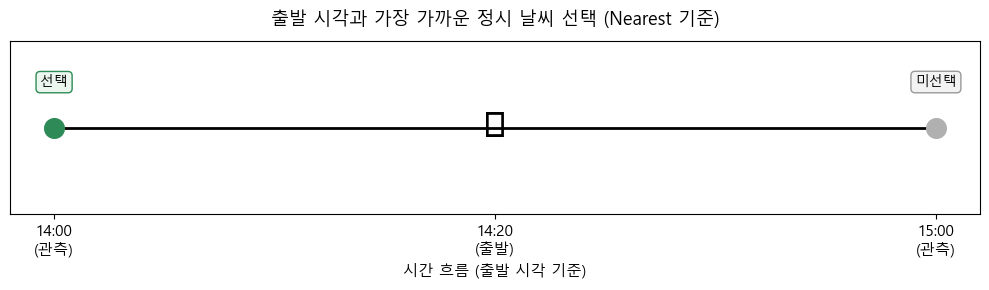

In [15]:
import matplotlib.pyplot as plt

times = ["14:00\n(관측)", "14:20\n(출발)", "15:00\n(관측)"]
x = [0, 1, 2]
y = [0, 0, 0]

plt.figure(figsize=(10, 3))

# 시간 축
plt.plot(x, y, linewidth=2, color="black")

# 원 (날씨 관측)
plt.scatter(x[0], y[0], s=200, color="#2E8B57", zorder=3)
plt.scatter(x[2], y[2], s=200, color="#B0B0B0", zorder=3)

# 출발 시점
plt.text(x[1], y[1], "✈", fontsize=26, ha="center", va="center", zorder=4)

# =========================
# 🔲 네모 박스를 '원 바로 위'에 밀착
# =========================
box_offset = 0.025  # ⭐ 핵심: 아주 작게

plt.text(
    x[0], y[0] + box_offset,
    "선택",
    ha="center",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#EAF6EE",
        edgecolor="#2E8B57"
    ),
    zorder=5
)

plt.text(
    x[2], y[2] + box_offset,
    "미선택",
    ha="center",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="#F2F2F2",
        edgecolor="#999999"
    ),
    zorder=5
)

# 축 설정
plt.xticks(x, times, fontsize=11)
plt.yticks([])
plt.xlabel("시간 흐름 (출발 시각 기준)", fontsize=11)

plt.title(
    "출발 시각과 가장 가까운 정시 날씨 선택 (Nearest 기준)",
    fontsize=13,
    pad=12
)

plt.tight_layout()
plt.savefig("ppt_weather_merge_nearest_time_box_attached.png", dpi=200)
plt.show()
